In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [26]:
def process():
    Day,RV,RVU = np.loadtxt('RCV.tbl.txt', skiprows=22, unpack=True)
    return(Day,RV,RVU)

In [27]:
Day, RV, RVU = process()
print(Day[0])


2449676.0632


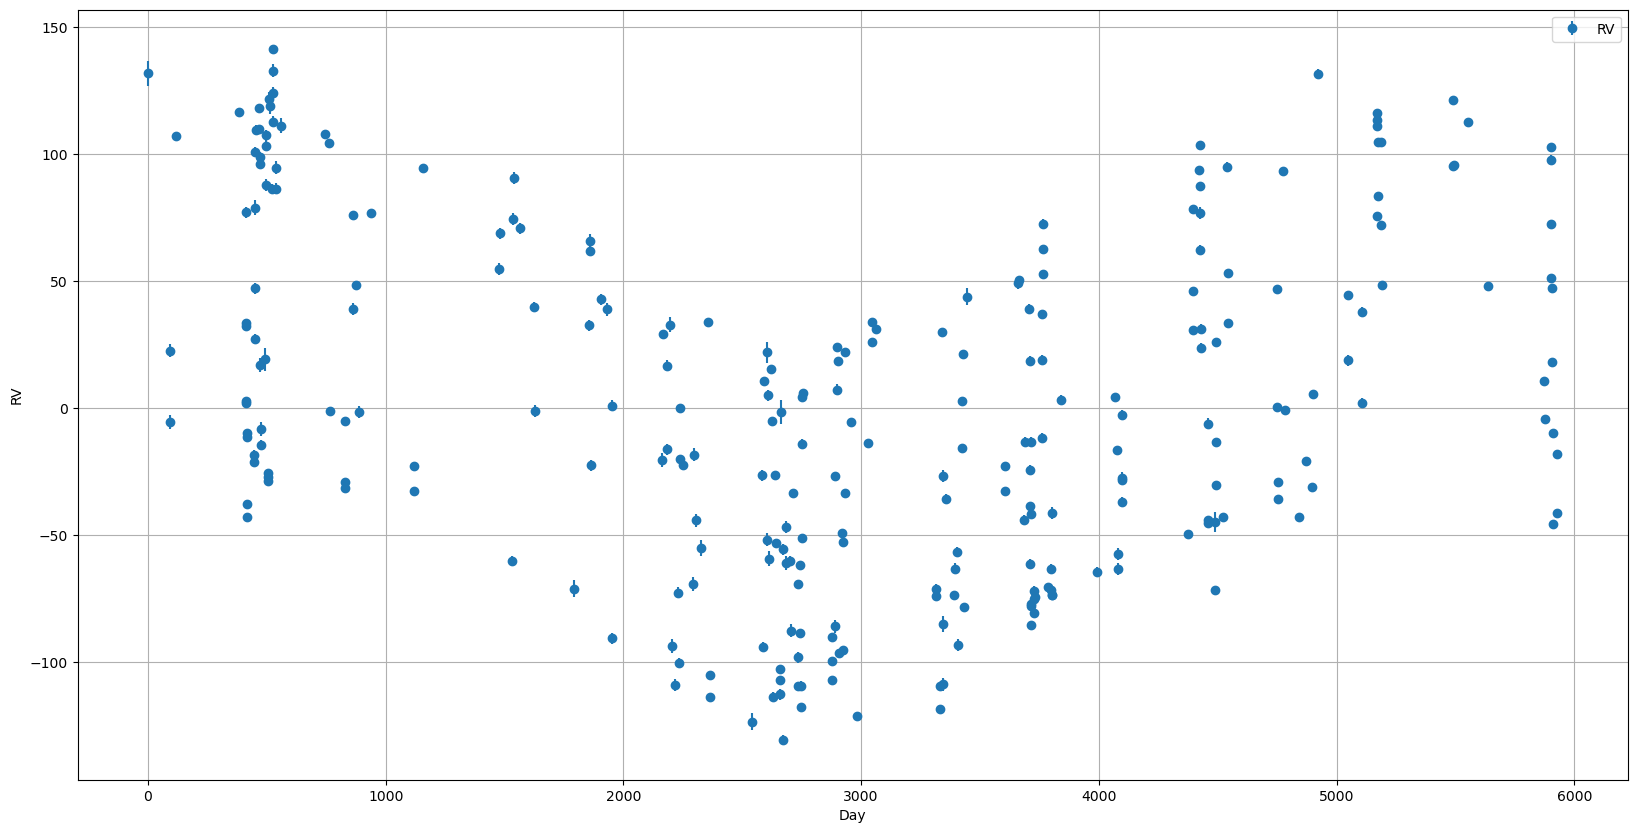

In [28]:
plt.figure(figsize=(20, 10))

plt.errorbar(Day - Day[0], RV, yerr=RVU, fmt='o', label='RV') 
plt.xlabel('Day')
plt.ylabel('RV')
plt.legend()
plt.grid(True)
plt.show()


In [29]:
def f_model(x, a,b,c,d):
    return a * np.sin(( 2 * np.pi * (x - b) ) / c) + d

In [57]:
guess_params = [125, -170, 4500, 25]
#guess_params = [125, -170, 4500, 25]
best_params, _ = optimize.curve_fit(f_model, Day - Day[0], RV, p0=guess_params)
best_a = best_params[0]
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]
print(best_params)

[ 5.43926341e+01 -5.88293418e+02  4.77736070e+03  1.08236843e-01]


In [60]:
x_fit = np.linspace(min(Day - Day[0]), max(Day - Day[0]), len(Day))
y_fit = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

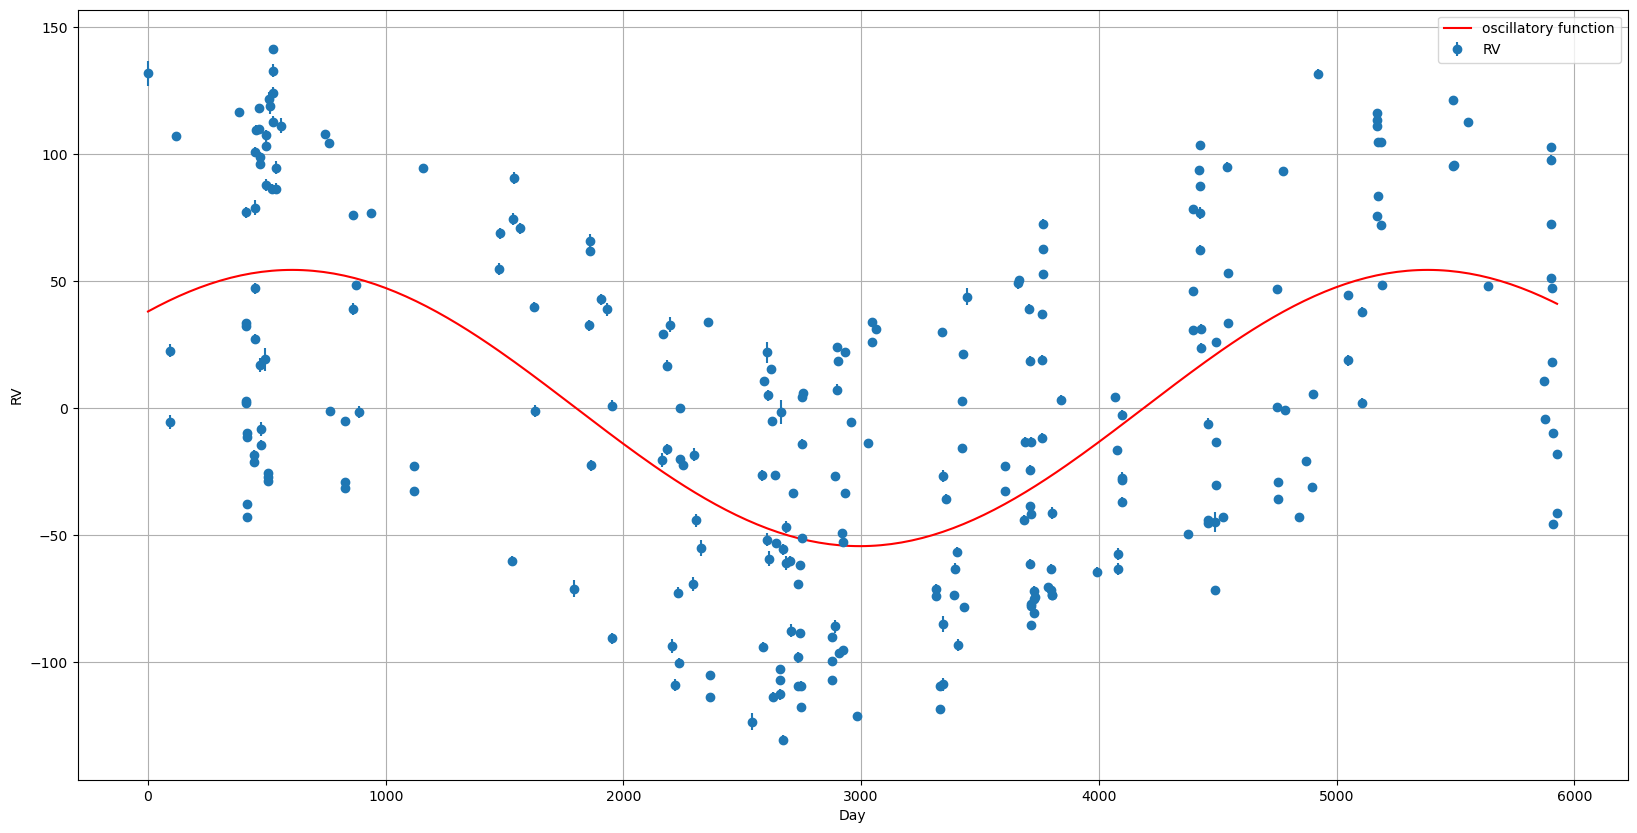

In [61]:
plt.figure(figsize=(20, 10))
plt.errorbar(Day - Day[0], RV, yerr=RVU, fmt='o', label='RV')
plt.plot(x_fit, y_fit, 'r-', label='oscillatory function')
plt.xlabel('Day')
plt.ylabel('RV')
#RV stands for radial velocity
plt.legend()
plt.grid(True)
plt.show()

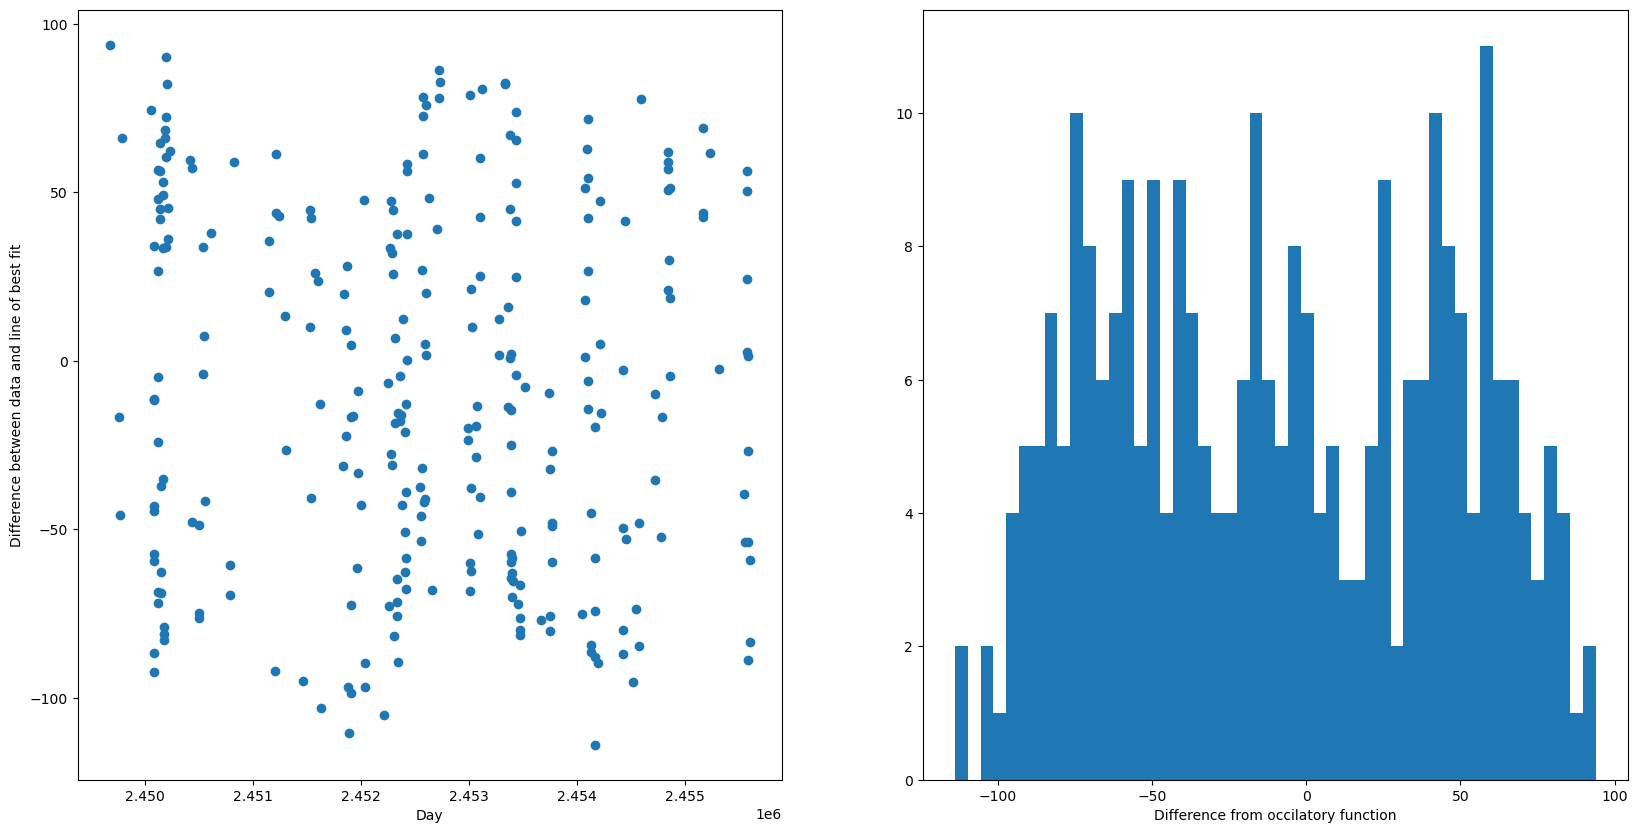

In [53]:
y_residuals = RV - y_fit
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].scatter(Day,y_residuals)
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Difference between data and line of best fit')
ax[1].hist(y_residuals,bins=50)
ax[1].set_xlabel('Difference from occilatory function')
fig.savefig('residuals_graph.png')

[ -20.39457085 -782.71182809 2259.39564128  -11.00855506]


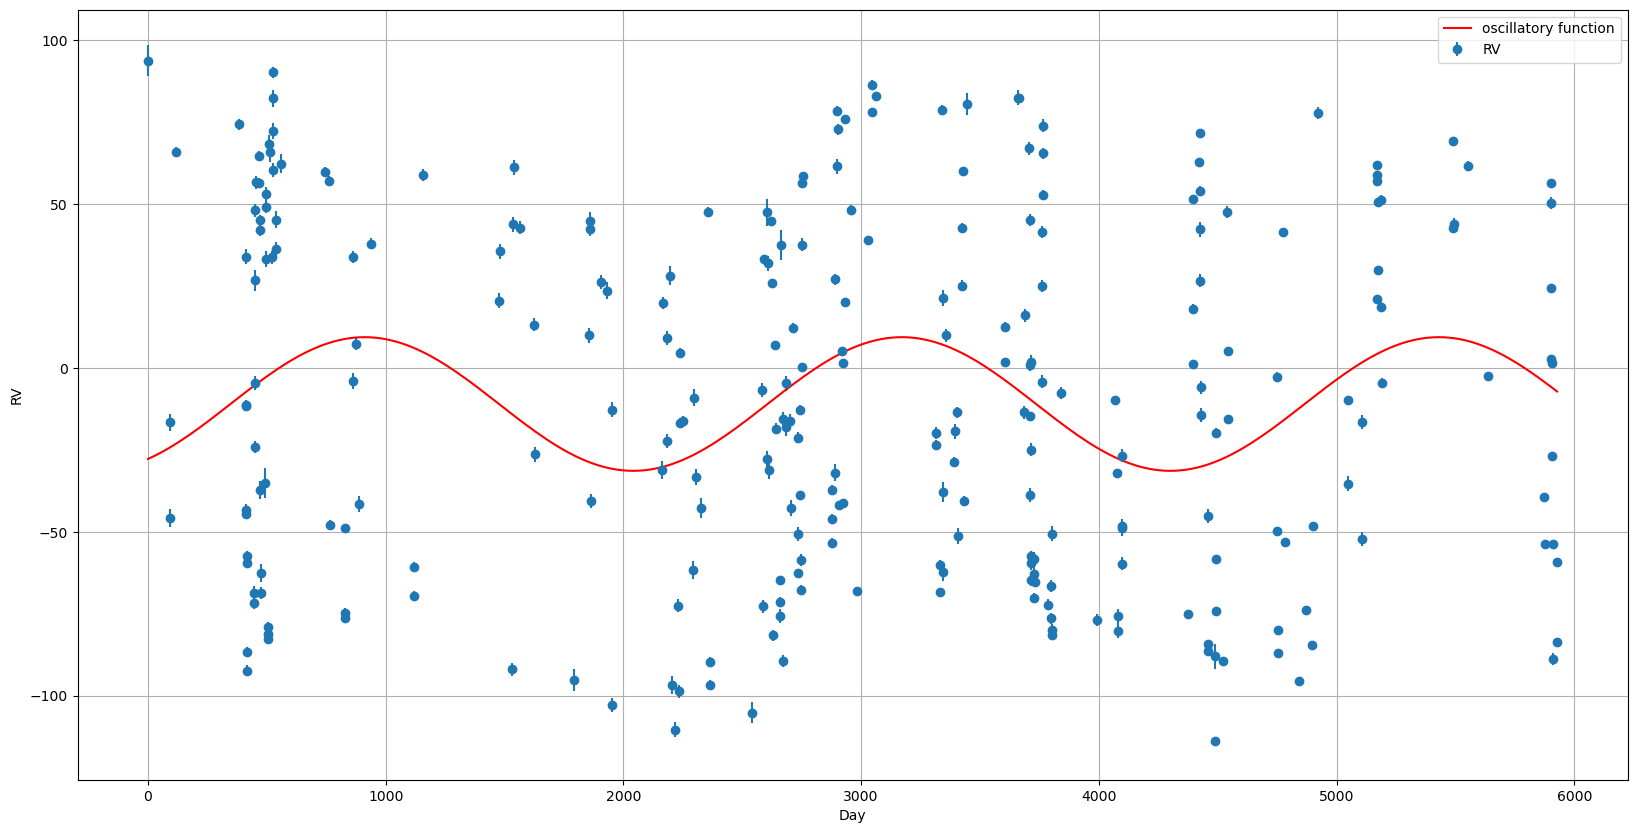

In [70]:
def g_model(x, a,b,c,d):
    return a * np.sin(( 2 * np.pi * (x - b) ) / c) + d

guess_params = [125, -170, 2000, 10]
#guess_params = [125, -170, 4500, 25]
best_params, _ = optimize.curve_fit(g_model, Day - Day[0], y_residuals, p0=guess_params)
best_a = best_params[0]
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]
print(best_params)

y_fit_two = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

plt.figure(figsize=(20, 10))
plt.errorbar(Day - Day[0], y_residuals, yerr=RVU, fmt='o', label='RV')
plt.plot(x_fit, y_fit_two, 'r-', label='oscillatory function')
plt.xlabel('Day')
plt.ylabel('RV')
#RV stands for radial velocity
plt.legend()
plt.grid(True)
plt.show()

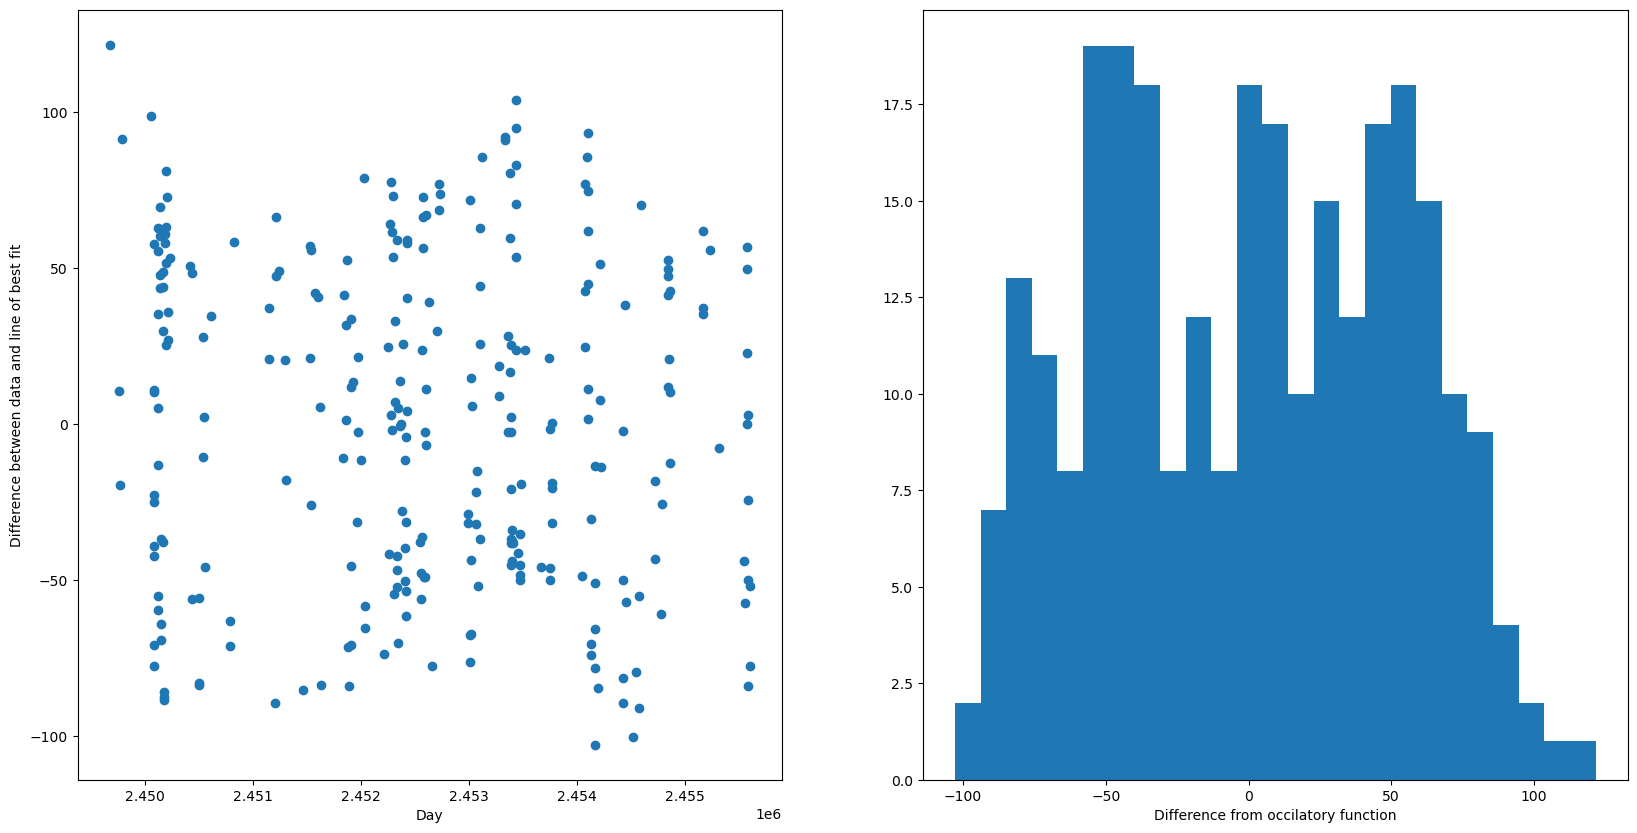

In [71]:
y_residuals_two = y_residuals - y_fit_two
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].scatter(Day,y_residuals_two)
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Difference between data and line of best fit')
ax[1].hist(y_residuals_two,bins=25)
ax[1].set_xlabel('Difference from occilatory function')
fig.savefig('residuals_graph.png')

[-7.51292884e+00  8.74633663e+02  3.15036052e+03 -1.29354210e+00]


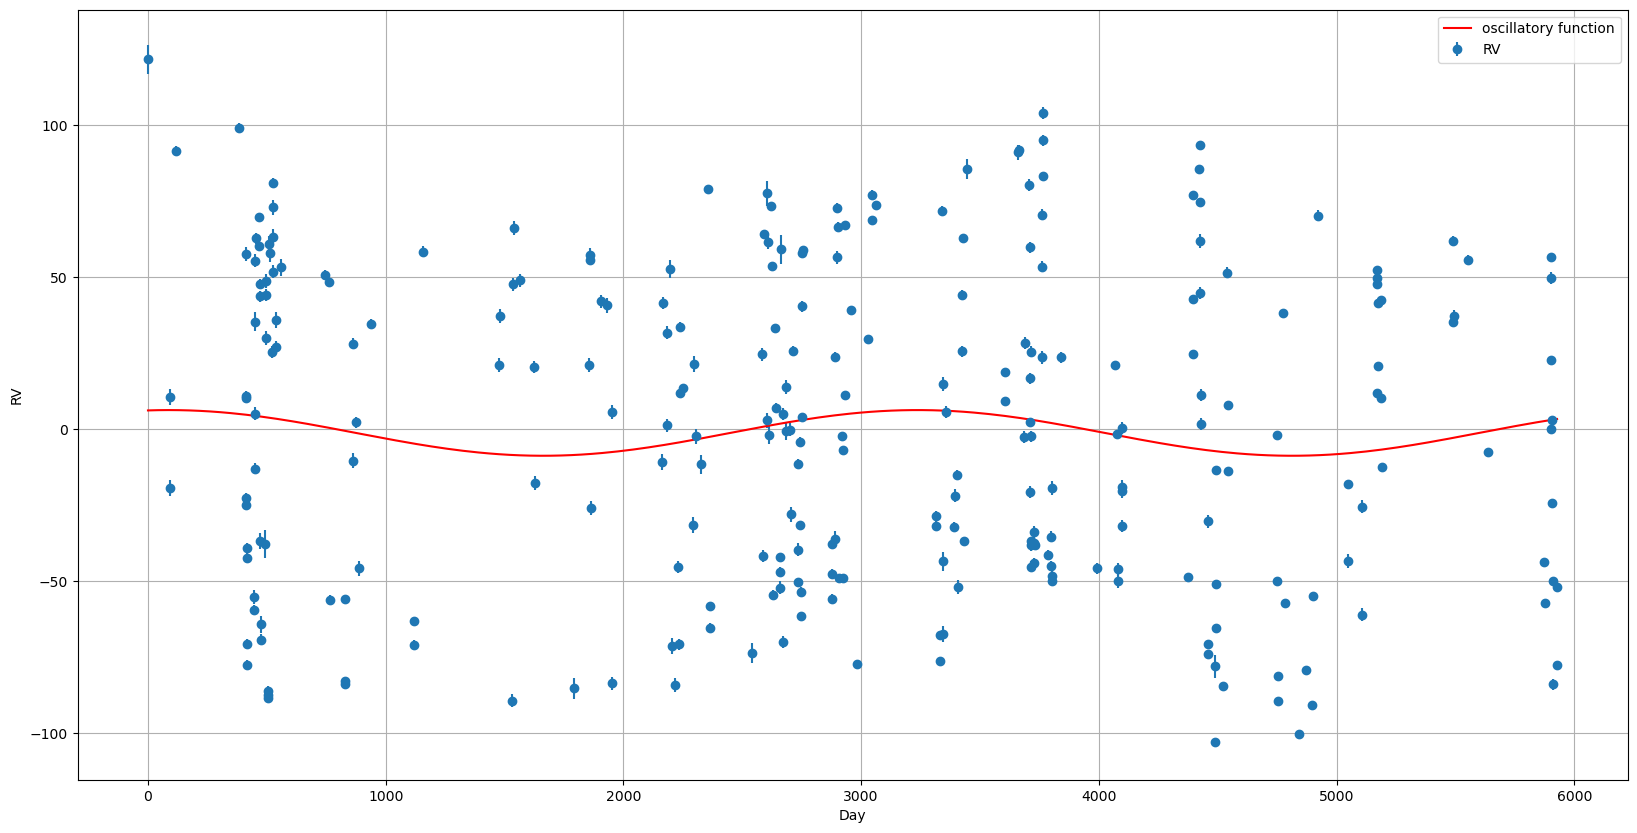

In [85]:
def h_model(x, a,b,c,d):
    return a * np.sin(( 2 * np.pi * (x - b) ) / c) + d

guess_params = [500, 170, 4000, -10]
#guess_params = [125, -170, 4500, 25]
best_params, _ = optimize.curve_fit(h_model, Day - Day[0], y_residuals_two, p0=guess_params)
best_a = best_params[0]
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]
print(best_params)

y_fit_three = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

plt.figure(figsize=(20, 10))
plt.errorbar(Day - Day[0], y_residuals_two, yerr=RVU, fmt='o', label='RV')
plt.plot(x_fit, y_fit_three, 'r-', label='oscillatory function')
plt.xlabel('Day')
plt.ylabel('RV')
#RV stands for radial velocity
plt.legend()
plt.grid(True)
plt.show()

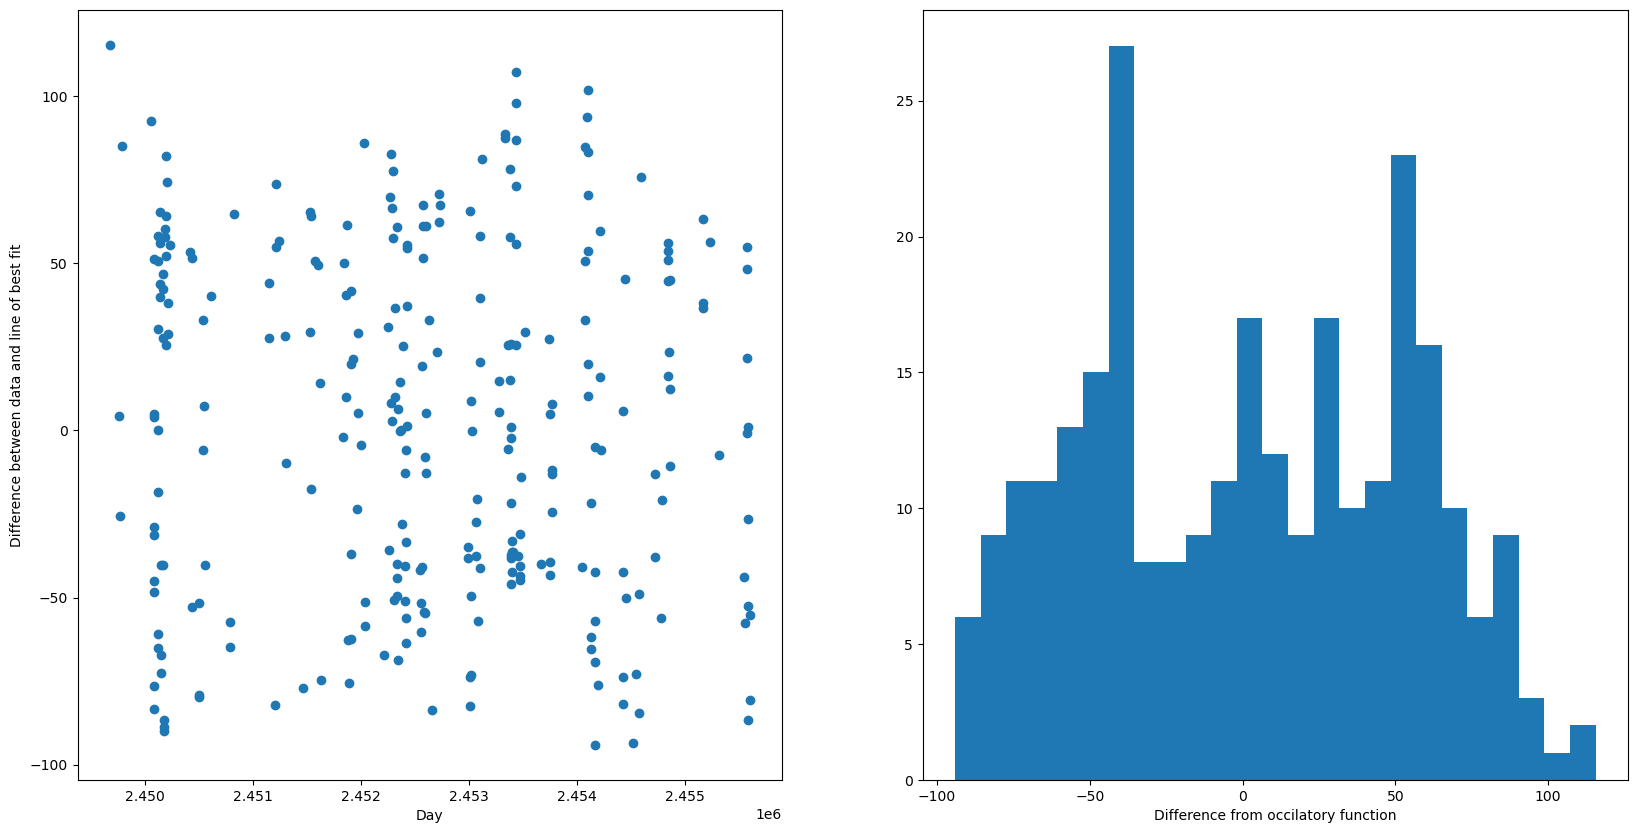

In [87]:
y_residuals_three = y_residuals_two - y_fit_three
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].scatter(Day,y_residuals_three)
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Difference between data and line of best fit')
ax[1].hist(y_residuals_three,bins=25)
ax[1].set_xlabel('Difference from occilatory function')
fig.savefig('residuals_graph.png')